# Improving LSTM Sales Forecasting — Store 44
---
**Objective**: Memperbaiki performa model LSTM agar dapat mengungguli model baseline (Seasonal Naive, XGBoost, RNN) dalam memprediksi penjualan di Store 44 untuk family GROCERY I, HARDWARE, dan LAWN AND GARDEN.

**Perbaikan Utama dari Notebook Asli (`notebook-utama.ipynb`)**:
1. **Arsitektur Stacked 2-Layer LSTM** (vs single layer pada notebook asli)
2. **Enhanced Feature Engineering**: fitur temporal, lag, dan rolling statistics
3. **Lookback lebih panjang**: `TIME_STEPS = 30` (vs 14)
4. **Konfigurasi training yang lebih baik**: `shuffle=False`, batch size lebih kecil, `ReduceLROnPlateau`
5. **Ruang pencarian hyperparameter lebih luas**: unit lebih besar [32, 64, 128]

---
**Referensi masalah pada notebook asli:**

| Family | Model | MAE | RMSLE |
|--------|-------|-----|-------|
| GROCERY I | XGBoost | 1731.99 | 0.7443 |
| GROCERY I | ❌ LSTM Tuned | 2695.93 | 0.7487 |
| HARDWARE | ✅ LSTM Tuned | 2.15 | 0.6069 |
| LAWN AND GARDEN | Seasonal Naive | 12.54 | 0.7250 |
| LAWN AND GARDEN | ❌ LSTM Tuned | 13.41 | 0.7711 |

In [1]:
# =============================================================
# Library Imports
# =============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_log_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, SimpleRNN, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Seed untuk Reproduksibilitas (sama dengan notebook asli)
SEED = 10122097
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seed: {SEED}")
print(f"TensorFlow version: {tf.__version__}")

Random seed: 10122097
TensorFlow version: 2.21.0


## 1. Data Loading
---

In [2]:
# Memuat Data
train = pd.read_csv("datasets/train.csv", parse_dates=['date'])
test = pd.read_csv("datasets/test.csv", parse_dates=['date'])
oil = pd.read_csv("datasets/oil.csv", parse_dates=['date'])
holidays = pd.read_csv("datasets/holidays_events.csv", parse_dates=['date'])
stores = pd.read_csv("datasets/stores.csv")
transactions = pd.read_csv("datasets/transactions.csv", parse_dates=['date'])

print(f"Train shape: {train.shape}")
print(f"Date range: {train['date'].min()} to {train['date'].max()}")
print(f"Unique stores: {train['store_nbr'].nunique()}")
print(f"Unique families: {train['family'].nunique()}")

Train shape: (3000888, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Unique stores: 54
Unique families: 33


In [3]:
# =============================================================
# Konfigurasi Skenario dan Parameter
# =============================================================
scenarios = [
    (44, 'GROCERY I'),
    (44, 'LAWN AND GARDEN'),
    (44, 'HARDWARE')
]

# PENINGKATAN: TIME_STEPS diperbesar dari 14 menjadi 30
# untuk menangkap pola musiman bulanan yang lebih panjang
TIME_STEPS = 30

print(f"TIME_STEPS: {TIME_STEPS} (asli: 14)")
print(f"Skenario: {scenarios}")

TIME_STEPS: 30 (asli: 14)
Skenario: [(44, 'GROCERY I'), (44, 'LAWN AND GARDEN'), (44, 'HARDWARE')]


## 2. Enhanced Feature Engineering
---
**Perbedaan dari notebook asli:**

| Aspek | Notebook Asli | Notebook Perbaikan |
|-------|--------------|-------------------|
| Fitur eksternal | `onpromotion`, `oil_price`, `is_holiday` (3) | + `day_of_week`, `month`, `is_weekend`, `lag_7`, `lag_14`, `rolling_mean_7`, `rolling_std_7` (10 total) |
| TIME_STEPS | 14 | 30 |
| Total dimensi per time step | 4 (sales + 3 fitur) | 11 (sales + 10 fitur) |

**Alasan penambahan fitur:**
- **Temporal features**: `day_of_week`, `month`, `is_weekend` — menangkap pola mingguan dan musiman yang kuat pada data grocery
- **Lag features**: `lag_7`, `lag_14` — memberikan sinyal eksplisit tentang pola berulang mingguan
- **Rolling statistics**: `rolling_mean_7`, `rolling_std_7` — menangkap tren dan volatilitas terkini

In [4]:
# =============================================================
# Fungsi-Fungsi Pembantu
# =============================================================

def evaluate_metrics(y_true, y_pred):
    # Menghitung MAE dan RMSLE
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    return mae, rmsle

def create_sequences(X, y, time_steps):
    # Membentuk tensor 3D dari data sekuensial
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

print("Fungsi pembantu berhasil didefinisikan.")

Fungsi pembantu berhasil didefinisikan.


In [5]:
# =============================================================
# Enhanced Feature Engineering dengan MinMaxScaler
# =============================================================
print("Memulai Enhanced Feature Engineering untuk semua skenario...")

processed_data = {}

for store, family in scenarios:
    print(f"\n--- Processing: Store {store} | Family {family} ---")

    # --- A. Data Filtering (sama dengan asli) ---
    df_sub = train[(train['store_nbr'] == store) & (train['family'] == family)].copy()
    df_sub = df_sub.groupby('date')[['sales', 'onpromotion']].sum().reset_index()
    df_sub = df_sub.set_index('date').asfreq('D').fillna(0)

    # --- B. External Features (sama dengan asli) ---
    oil_daily = oil.set_index('date').asfreq('D')
    oil_daily['dcoilwtico'] = oil_daily['dcoilwtico'].ffill().bfill()
    df_model = df_sub.join(oil_daily).rename(columns={'dcoilwtico': 'oil_price'})

    holidays_filtered = holidays[holidays['transferred'] == False].set_index('date')
    df_model['is_holiday'] = df_model.index.isin(holidays_filtered.index).astype(int)

    # --- C. BARU: Fitur Temporal ---
    df_model['day_of_week'] = df_model.index.dayofweek      # 0=Monday, 6=Sunday
    df_model['month'] = df_model.index.month                  # 1-12
    df_model['is_weekend'] = (df_model.index.dayofweek >= 5).astype(int)

    # --- D. BARU: Lag Features ---
    df_model['lag_7'] = df_model['sales'].shift(7)
    df_model['lag_14'] = df_model['sales'].shift(14)

    # --- E. BARU: Rolling Statistics ---
    df_model['rolling_mean_7'] = df_model['sales'].rolling(window=7).mean()
    df_model['rolling_std_7'] = df_model['sales'].rolling(window=7).std()

    # Hapus baris NaN (dari lag dan rolling)
    df_model = df_model.dropna()
    print(f"  Data shape setelah feature engineering: {df_model.shape}")

    # --- F. Scaling (MinMaxScaler, sama dengan asli) ---
    feature_cols = [
        'onpromotion', 'oil_price', 'is_holiday',
        'day_of_week', 'month', 'is_weekend',
        'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7'
    ]
    X_data = df_model[feature_cols]
    y_data = df_model['sales']

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_data)
    y_scaled = scaler_y.fit_transform(y_data.values.reshape(-1, 1))

    # --- G. Pembentukan Tensor ---
    combined_scaled = np.hstack((y_scaled, X_scaled))  # sales di index 0
    X_seq, y_seq = [], []
    y_actual = y_data.values

    for i in range(len(combined_scaled) - TIME_STEPS):
        X_seq.append(combined_scaled[i : i + TIME_STEPS])
        y_seq.append(combined_scaled[i + TIME_STEPS, 0])

    X_seq, y_seq = np.array(X_seq), np.array(y_seq)
    y_actual_seq = y_actual[TIME_STEPS:]

    # --- H. Train/Test Split (80/20 kronologis) ---
    train_size = int(len(X_seq) * 0.8)

    processed_data[(store, family)] = {
        'X_train_3d': X_seq[:train_size],
        'X_test_3d': X_seq[train_size:],
        'y_train_scaled': y_seq[:train_size],
        'y_test_scaled': y_seq[train_size:],
        'y_test_actual': y_actual_seq[train_size:],
        'scaler_y': scaler_y,
        'feature_cols': feature_cols
    }

    print(f"  X_train shape: {X_seq[:train_size].shape}")
    print(f"  X_test shape:  {X_seq[train_size:].shape}")

print(f"\nFeature Engineering selesai. {len(processed_data)} set tensor disimpan.")
print(f"Fitur per time step: {len(feature_cols) + 1} (sales + {len(feature_cols)} fitur)")

Memulai Enhanced Feature Engineering untuk semua skenario...

--- Processing: Store 44 | Family GROCERY I ---
  Data shape setelah feature engineering: (1674, 11)
  X_train shape: (1315, 30, 11)
  X_test shape:  (329, 30, 11)

--- Processing: Store 44 | Family LAWN AND GARDEN ---
  Data shape setelah feature engineering: (1674, 11)
  X_train shape: (1315, 30, 11)
  X_test shape:  (329, 30, 11)

--- Processing: Store 44 | Family HARDWARE ---
  Data shape setelah feature engineering: (1674, 11)
  X_train shape: (1315, 30, 11)
  X_test shape:  (329, 30, 11)

Feature Engineering selesai. 3 set tensor disimpan.
Fitur per time step: 11 (sales + 10 fitur)


In [6]:
# =============================================================
# Inspeksi Struktur Tensor
# =============================================================
for (store, family), data in processed_data.items():
    print(f"=== Store {store} - Family {family} ===")
    print(f"  X_train_3d: {data['X_train_3d'].shape} -> (samples, {TIME_STEPS} timesteps, {data['X_train_3d'].shape[2]} features)")
    print(f"  X_test_3d:  {data['X_test_3d'].shape}")
    print(f"  y_train:    {data['y_train_scaled'].shape}")
    print(f"  y_test:     {data['y_test_actual'].shape}")
    print()

=== Store 44 - Family GROCERY I ===
  X_train_3d: (1315, 30, 11) -> (samples, 30 timesteps, 11 features)
  X_test_3d:  (329, 30, 11)
  y_train:    (1315,)
  y_test:     (329,)

=== Store 44 - Family LAWN AND GARDEN ===
  X_train_3d: (1315, 30, 11) -> (samples, 30 timesteps, 11 features)
  X_test_3d:  (329, 30, 11)
  y_train:    (1315,)
  y_test:     (329,)

=== Store 44 - Family HARDWARE ===
  X_train_3d: (1315, 30, 11) -> (samples, 30 timesteps, 11 features)
  X_test_3d:  (329, 30, 11)
  y_train:    (1315,)
  y_test:     (329,)



## 3. Model Baseline (Direplikasi dari Notebook Asli)
---
Melatih tiga model baseline dengan arsitektur dan hyperparameter **yang sama** dengan notebook asli, namun menggunakan fitur yang telah ditingkatkan agar perbandingan adil.

Model baseline:
1. **Seasonal Naive** — menggunakan nilai 7 hari lalu sebagai prediksi
2. **XGBoost** — gradient boosting dengan flattened features
3. **Simple RNN** — 2-layer RNN (64→32 units), sama persis dengan notebook asli

In [7]:
# =============================================================
# Pelatihan Model Baseline: Seasonal Naive, XGBoost, RNN
# =============================================================
all_results = []

early_stop_baseline = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=0
)

start_time = time.time()

for (store, family), data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"  MELATIH BASELINE: STORE {store} | FAMILY {family}")
    print(f"{'='*60}")

    X_train_3d = data['X_train_3d']
    X_test_3d = data['X_test_3d']
    y_train_scaled = data['y_train_scaled']
    y_test_actual = data['y_test_actual']
    scaler_y = data['scaler_y']

    # --- Model 1: Seasonal Naive ---
    print("-> Mengevaluasi Seasonal Naive...")
    snaive_scaled_preds = X_test_3d[:, (TIME_STEPS - 7), 0]  # Nilai 7 hari lalu
    snaive_preds = scaler_y.inverse_transform(snaive_scaled_preds.reshape(-1, 1)).flatten()
    snaive_preds = np.maximum(snaive_preds, 0)
    mae_sn, rmsle_sn = evaluate_metrics(y_test_actual, snaive_preds)
    all_results.append({'Store': store, 'Family': family, 'Model': 'Seasonal Naive', 'MAE': mae_sn, 'RMSLE': rmsle_sn})
    print(f"   MAE: {mae_sn:.4f} | RMSLE: {rmsle_sn:.6f}")

    # Simpan prediksi untuk plotting nanti
    data['snaive_preds'] = snaive_preds

    # --- Model 2: XGBoost ---
    print("-> Melatih XGBoost...")
    X_train_2d = X_train_3d.reshape(X_train_3d.shape[0], -1)
    X_test_2d = X_test_3d.reshape(X_test_3d.shape[0], -1)
    xgb_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED, n_jobs=-1)
    xgb_model.fit(X_train_2d, y_train_scaled, eval_set=[(X_train_2d, y_train_scaled)], verbose=False)
    xgb_preds_scaled = xgb_model.predict(X_test_2d)
    xgb_preds = scaler_y.inverse_transform(xgb_preds_scaled.reshape(-1, 1)).flatten()
    xgb_preds = np.maximum(xgb_preds, 0)
    mae_xgb, rmsle_xgb = evaluate_metrics(y_test_actual, xgb_preds)
    all_results.append({'Store': store, 'Family': family, 'Model': 'XGBoost', 'MAE': mae_xgb, 'RMSLE': rmsle_xgb})
    print(f"   MAE: {mae_xgb:.4f} | RMSLE: {rmsle_xgb:.6f}")

    data['xgb_preds'] = xgb_preds

    # --- Model 3: Simple RNN (arsitektur SAMA dengan notebook asli) ---
    print("-> Melatih Simple RNN (64->32, sama dengan asli)...")
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    rnn_model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=(X_train_3d.shape[1], X_train_3d.shape[2]), return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32, activation='tanh'),
        Dense(1)
    ])
    rnn_model.compile(optimizer='adam', loss='mse')
    rnn_model.fit(X_train_3d, y_train_scaled, epochs=50, batch_size=32,
                  validation_split=0.1, verbose=0, callbacks=[early_stop_baseline])
    rnn_preds_scaled = rnn_model.predict(X_test_3d, verbose=0)
    rnn_preds = scaler_y.inverse_transform(rnn_preds_scaled).flatten()
    rnn_preds = np.maximum(rnn_preds, 0)
    mae_rnn, rmsle_rnn = evaluate_metrics(y_test_actual, rnn_preds)
    all_results.append({'Store': store, 'Family': family, 'Model': 'RNN', 'MAE': mae_rnn, 'RMSLE': rmsle_rnn})
    print(f"   MAE: {mae_rnn:.4f} | RMSLE: {rmsle_rnn:.6f}")

    data['rnn_preds'] = rnn_preds

elapsed = time.time() - start_time
print(f"\nBaseline selesai dalam {elapsed:.1f} detik")


  MELATIH BASELINE: STORE 44 | FAMILY GROCERY I
-> Mengevaluasi Seasonal Naive...
   MAE: 1974.4438 | RMSLE: 0.799626
-> Melatih XGBoost...
   MAE: 1855.8961 | RMSLE: 0.766784
-> Melatih Simple RNN (64->32, sama dengan asli)...

   MAE: 2028.3600 | RMSLE: 0.775618

  MELATIH BASELINE: STORE 44 | FAMILY LAWN AND GARDEN
-> Mengevaluasi Seasonal Naive...
   MAE: 12.6778 | RMSLE: 0.719429
-> Melatih XGBoost...
   MAE: 11.8187 | RMSLE: 0.655781
-> Melatih Simple RNN (64->32, sama dengan asli)...
   MAE: 15.8600 | RMSLE: 0.962053

  MELATIH BASELINE: STORE 44 | FAMILY HARDWARE
-> Mengevaluasi Seasonal Naive...
   MAE: 2.5350 | RMSLE: 0.715194
-> Melatih XGBoost...
   MAE: 2.1880 | RMSLE: 0.616403
-> Melatih Simple RNN (64->32, sama dengan asli)...
   MAE: 2.0914 | RMSLE: 0.608339

Baseline selesai dalam 172.4 detik


In [8]:
# =============================================================
# Tabel Hasil Baseline
# =============================================================
df_baseline = pd.DataFrame(all_results)
print("=== Hasil Model Baseline ===")
display(df_baseline.sort_values(by=['Family', 'MAE']).reset_index(drop=True).round(4))

=== Hasil Model Baseline ===


,Store,Family,Model,MAE,RMSLE
0,44,GROCERY I,XGBoost,1855.8961,0.7668
1,44,GROCERY I,Seasonal Naive,1974.4438,0.7996
2,44,GROCERY I,RNN,2028.3600,0.7756
3,44,HARDWARE,RNN,2.0914,0.6083
4,44,HARDWARE,XGBoost,2.1880,0.6164
5,44,HARDWARE,Seasonal Naive,2.5350,0.7152
6,44,LAWN AND GARDEN,XGBoost,11.8187,0.6558
7,44,LAWN AND GARDEN,Seasonal Naive,12.6778,0.7194
8,44,LAWN AND GARDEN,RNN,15.8600,0.9621


## 4. Pengembangan Model LSTM yang Ditingkatkan
---
**7 perbaikan kritis dari notebook asli:**

| # | Masalah di Notebook Asli | Perbaikan |
|---|-------------------------|-----------|
| 1 | Single LSTM layer (1 layer) | **Stacked 2-layer LSTM** (units → units//2) |
| 2 | Unit terlalu kecil [10, 30, 50] | **Unit lebih besar** [32, 64, 128] |
| 3 | TIME_STEPS=14 (2 minggu) | **TIME_STEPS=30** (1 bulan) |
| 4 | `batch_size=128` (terlalu besar) | **`batch_size=32`** |
| 5 | `shuffle=True` (merusak urutan temporal!) | **`shuffle=False`** |
| 6 | `patience=10` (terlalu agresif) | **`patience=20`** + `ReduceLROnPlateau` |
| 7 | Hanya 3 fitur eksternal | **10 fitur** (temporal + lag + rolling) |

### Arsitektur Model Baru:
```
Input(shape=(30, 11))
  → LSTM(units, return_sequences=True, dropout=dr)
  → LSTM(units//2, dropout=dr)
  → Dense(16, activation='relu')
  → Dense(1)
```

In [9]:
# =============================================================
# Fungsi Pembantu untuk LSTM Tuning & Evaluasi
# =============================================================

def build_improved_lstm(units, dropout_rate, learning_rate, input_shape):
    # Membangun model LSTM yang ditingkatkan dengan arsitektur stacked 2-layer.
    # Perbedaan vs asli:
    # - 2 LSTM layers (return_sequences=True pada layer pertama)
    # - Dense intermediate layer (16 units, ReLU)
    # - Unit layer kedua = units // 2
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = Sequential([
        Input(shape=input_shape),
        LSTM(units, return_sequences=True, dropout=dropout_rate),
        LSTM(units // 2, dropout=dropout_rate),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer)
    return model


def plot_loss_history(history, title='Loss Function History'):
    # Plot training vs validation loss
    plt.figure(figsize=(12, 5))
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
    plt.title(title, fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def evaluate_and_print(y_true, y_pred, label='Model'):
    # Evaluasi dan cetak MAE serta RMSLE
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    print(f"  [{label}] MAE  = {mae:.4f}")
    print(f"  [{label}] RMSLE = {rmsle:.6f}")
    return mae, rmsle


def plot_actual_vs_predicted(y_actual, y_pred, title='Actual vs Predicted', last_n=150):
    # Plot perbandingan data asli vs prediksi
    plt.figure(figsize=(15, 6))
    plt.plot(y_actual[-last_n:], label='Data Asli (Actual)', color='black', linewidth=2, alpha=0.7)
    plt.plot(y_pred[-last_n:], label='Prediksi LSTM', color='red', linewidth=2, linestyle='--')
    plt.title(title, fontsize=14)
    plt.xlabel(f'Time Steps (Last {last_n} days)', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Fungsi pembantu LSTM berhasil didefinisikan.")

Fungsi pembantu LSTM berhasil didefinisikan.


### 4a. Hyperparameter Tuning LSTM (Reduced Grid)
---
**Grid pencarian** (27 kombinasi per skenario, 81 total):
- `units`: [32, 64, 128]
- `dropout_rate`: [0.1, 0.2, 0.3]
- `learning_rate`: [1e-2, 1e-3, 5e-4]
- `batch_size`: 32 (fixed)
- `epochs`: 200 (dengan early stopping)

**Perbaikan training**:
- `shuffle=False` — menjaga urutan temporal
- `patience=20` — memberi waktu konvergensi LSTM
- `ReduceLROnPlateau` — menurunkan learning rate saat konvergensi melambat

In [10]:
# =============================================================
# Hyperparameter Tuning LSTM untuk Semua Skenario
# =============================================================

# Ruang pencarian hyperparameter
param_units = [32, 64, 128]
param_dropout_rate = [0.1, 0.2, 0.3]
param_learning_rate = [1e-2, 1e-3, 5e-4]
BATCH_SIZE = 32
EPOCHS = 200

# Dictionary untuk menyimpan hasil
all_tuning_results = {}

tuning_start_time = time.time()

for (store, family), data in processed_data.items():
    print(f"\n{'='*70}")
    print(f"  TUNING LSTM: STORE {store} | FAMILY {family}")
    print(f"{'='*70}")

    X_train_full = data['X_train_3d']
    y_train_full = data['y_train_scaled']

    # Split manual untuk validation (80% train, 20% val) — kronologis
    split_idx = int(len(X_train_full) * 0.8)
    X_train_split = X_train_full[:split_idx]
    X_val_split = X_train_full[split_idx:]
    y_train_split = y_train_full[:split_idx]
    y_val_split = y_train_full[split_idx:]

    results = {}
    total_combos = len(param_units) * len(param_dropout_rate) * len(param_learning_rate)
    combo_count = 0
    scenario_start = time.time()

    for units in param_units:
        for dropout_rate in param_dropout_rate:
            for lr in param_learning_rate:
                combo_count += 1
                print(f'  [{combo_count}/{total_combos}] units={units}, dropout={dropout_rate}, lr={lr}', end=' ')

                model = build_improved_lstm(
                    units=units,
                    dropout_rate=dropout_rate,
                    learning_rate=lr,
                    input_shape=(X_train_full.shape[1], X_train_full.shape[2])
                )

                # Callbacks: Early Stopping + ReduceLROnPlateau
                early_stop = EarlyStopping(
                    monitor='val_loss',
                    patience=20,
                    restore_best_weights=True,
                    verbose=0
                )
                reduce_lr = ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=7,
                    min_lr=1e-6,
                    verbose=0
                )

                history = model.fit(
                    X_train_split, y_train_split,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_split, y_val_split),
                    callbacks=[early_stop, reduce_lr],
                    verbose=0,
                    shuffle=False  # PERBAIKAN: Menjaga urutan temporal!
                )

                best_val_loss = min(history.history['val_loss'])
                best_epoch = history.history['val_loss'].index(best_val_loss) + 1
                train_loss_at_best = history.history['loss'][best_epoch - 1]

                results[(units, dropout_rate, lr)] = {
                    'train_mse': train_loss_at_best,
                    'val_mse': best_val_loss,
                    'best_epoch': best_epoch,
                    'model': model,
                    'history': history
                }

                print(f'-> val_mse={best_val_loss:.6f} (epoch {best_epoch})')

    # Tentukan model terbaik
    best_key = min(results, key=lambda k: results[k]['val_mse'])
    best_result = results[best_key]
    scenario_elapsed = time.time() - scenario_start

    print(f"\n  >> Parameter Terbaik: units={best_key[0]}, dropout={best_key[1]}, lr={best_key[2]}")
    print(f"  >> Best Val MSE: {best_result['val_mse']:.6f} pada epoch {best_result['best_epoch']}")
    print(f"  >> Waktu: {scenario_elapsed:.1f} detik")

    all_tuning_results[(store, family)] = {
        'best_params': best_key,
        'all_results': results,
        'best_model': best_result['model'],
        'best_history': best_result['history']
    }

total_elapsed = time.time() - tuning_start_time
print(f"\nTuning selesai untuk semua {len(processed_data)} skenario dalam {total_elapsed:.1f} detik ({total_elapsed/60:.1f} menit)")


  TUNING LSTM: STORE 44 | FAMILY GROCERY I
  [1/27] units=32, dropout=0.1, lr=0.01 -> val_mse=0.002862 (epoch 42)
  [2/27] units=32, dropout=0.1, lr=0.001 -> val_mse=0.002883 (epoch 56)
  [3/27] units=32, dropout=0.1, lr=0.0005 -> val_mse=0.004748 (epoch 200)
  [4/27] units=32, dropout=0.2, lr=0.01 -> val_mse=0.003114 (epoch 37)
  [5/27] units=32, dropout=0.2, lr=0.001 -> val_mse=0.003193 (epoch 103)
  [6/27] units=32, dropout=0.2, lr=0.0005 -> val_mse=0.005029 (epoch 51)
  [7/27] units=32, dropout=0.3, lr=0.01 -> val_mse=0.002949 (epoch 40)
  [8/27] units=32, dropout=0.3, lr=0.001 -> val_mse=0.005134 (epoch 65)
  [9/27] units=32, dropout=0.3, lr=0.0005 -> val_mse=0.005077 (epoch 21)
  [10/27] units=64, dropout=0.1, lr=0.01 -> val_mse=0.002909 (epoch 43)
  [11/27] units=64, dropout=0.1, lr=0.001 -> val_mse=0.003127 (epoch 47)
  [12/27] units=64, dropout=0.1, lr=0.0005 -> val_mse=0.003568 (epoch 59)
  [13/27] units=64, dropout=0.2, lr=0.01 -> val_mse=0.003072 (epoch 28)
  [14/27] units

In [11]:
# =============================================================
# Tabel Rekapitulasi Hasil Tuning LSTM
# =============================================================

tuning_summary = []

for (store, family), res in all_tuning_results.items():
    for (units, dr, lr), vals in res['all_results'].items():
        tuning_summary.append({
            'Store': store,
            'Family': family,
            'Units': units,
            'Dropout': dr,
            'Learning Rate': lr,
            'Train MSE': vals['train_mse'],
            'Val MSE': vals['val_mse'],
            'Best Epoch': vals['best_epoch']
        })

df_tuning = pd.DataFrame(tuning_summary)
df_tuning = df_tuning.sort_values(by=['Family', 'Val MSE']).reset_index(drop=True)

print('=== Rekapitulasi Hasil Tuning LSTM ===')
display(df_tuning.round(6))

# Parameter terbaik per skenario
print('\n=== Parameter Terbaik per Skenario ===')
for (store, family), res in all_tuning_results.items():
    bp = res['best_params']
    print(f"  Store {store} - {family}: units={bp[0]}, dropout={bp[1]}, lr={bp[2]}")

=== Rekapitulasi Hasil Tuning LSTM ===


,Store,Family,Units,Dropout,Learning Rate,Train MSE,Val MSE,Best Epoch
0,44,GROCERY I,128,0.2,0.0010,0.003615,0.002788,43
1,44,GROCERY I,32,0.1,0.0100,0.003431,0.002862,42
2,44,GROCERY I,32,0.1,0.0010,0.003759,0.002883,56
3,44,GROCERY I,64,0.1,0.0100,0.003430,0.002909,43
4,44,GROCERY I,32,0.3,0.0100,0.003666,0.002949,40
...,...,...,...,...,...,...,...,...
76,44,LAWN AND GARDEN,32,0.3,0.0005,0.002119,0.001752,82
77,44,LAWN AND GARDEN,32,0.3,0.0010,0.001969,0.001759,71
78,44,LAWN AND GARDEN,64,0.2,0.0005,0.001837,0.001763,65
79,44,LAWN AND GARDEN,32,0.2,0.0005,0.002098,0.001772,47



=== Parameter Terbaik per Skenario ===
  Store 44 - GROCERY I: units=128, dropout=0.2, lr=0.001
  Store 44 - LAWN AND GARDEN: units=64, dropout=0.3, lr=0.001
  Store 44 - HARDWARE: units=32, dropout=0.2, lr=0.01


### 4b. Evaluasi Model LSTM Terbaik
---
Menampilkan loss function, evaluasi MAE/RMSLE, dan plot Actual vs Prediksi untuk setiap skenario.


  HASIL LSTM TERBAIK: STORE 44 | FAMILY GROCERY I
  Parameter Terbaik: units=128, dropout=0.2, lr=0.001


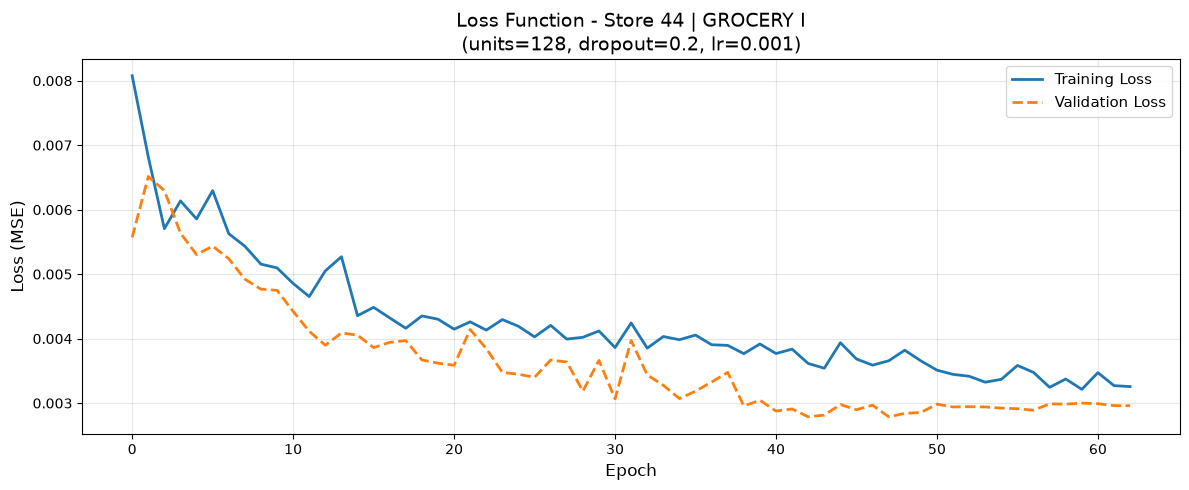


  Evaluasi pada Test Set:
  [LSTM Improved - GROCERY I] MAE  = 2023.5831
  [LSTM Improved - GROCERY I] RMSLE = 0.771527


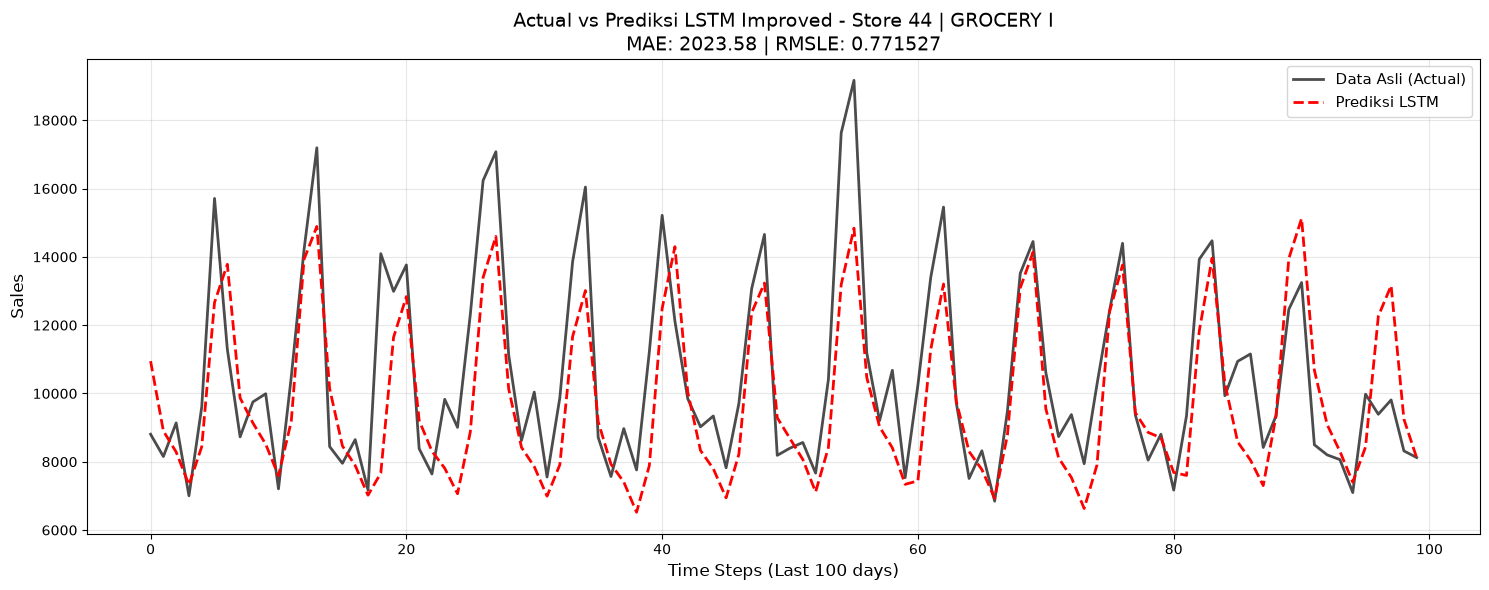


  HASIL LSTM TERBAIK: STORE 44 | FAMILY LAWN AND GARDEN
  Parameter Terbaik: units=64, dropout=0.3, lr=0.001


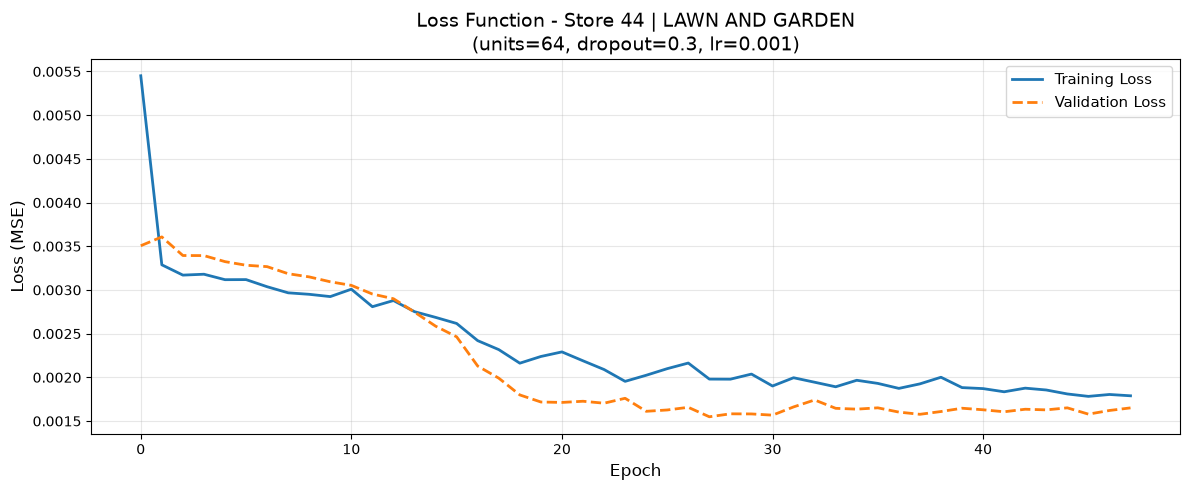


  Evaluasi pada Test Set:
  [LSTM Improved - LAWN AND GARDEN] MAE  = 15.3010
  [LSTM Improved - LAWN AND GARDEN] RMSLE = 0.961778


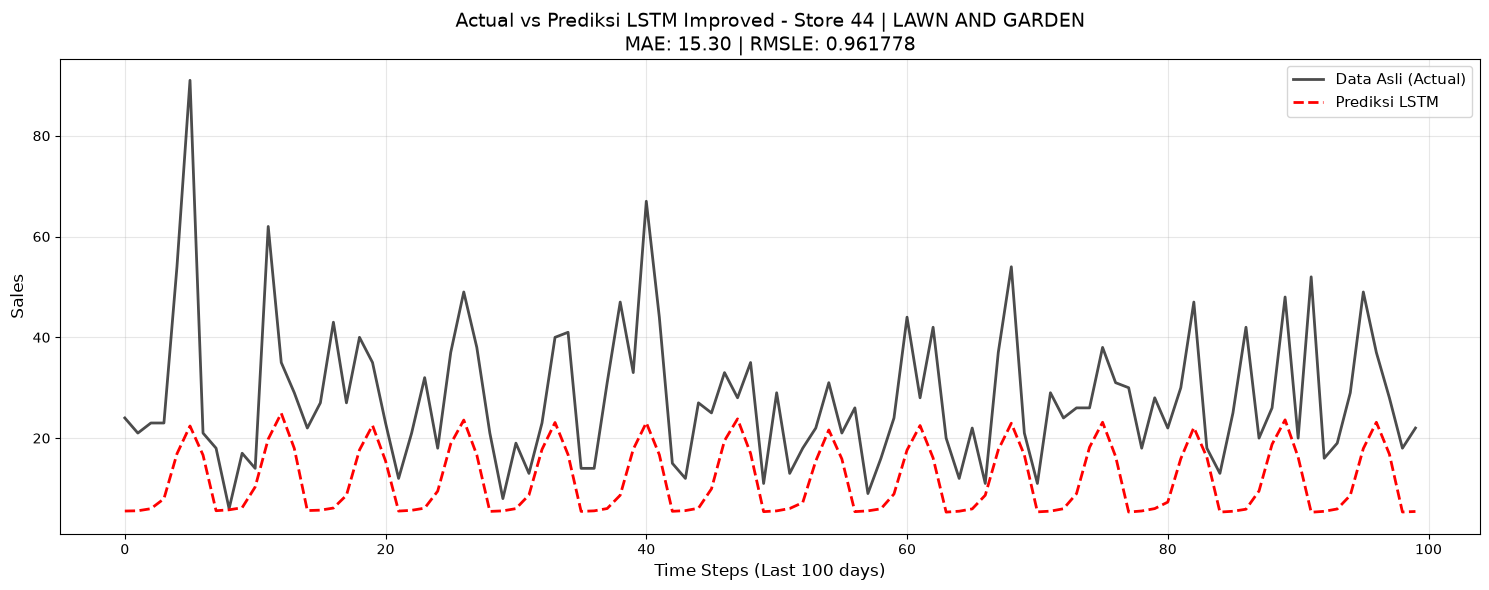


  HASIL LSTM TERBAIK: STORE 44 | FAMILY HARDWARE
  Parameter Terbaik: units=32, dropout=0.2, lr=0.01


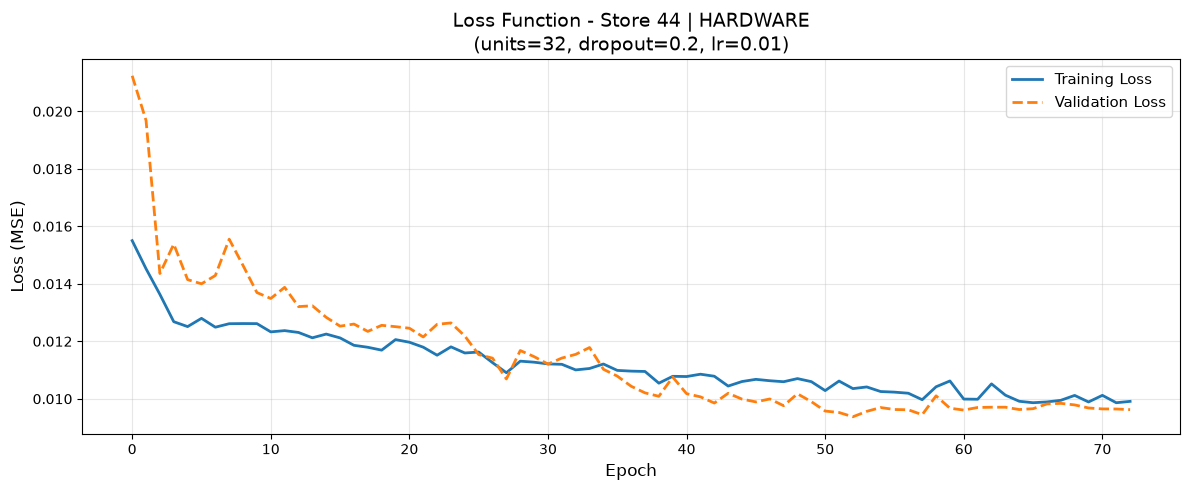


  Evaluasi pada Test Set:
  [LSTM Improved - HARDWARE] MAE  = 2.1033
  [LSTM Improved - HARDWARE] RMSLE = 0.607184


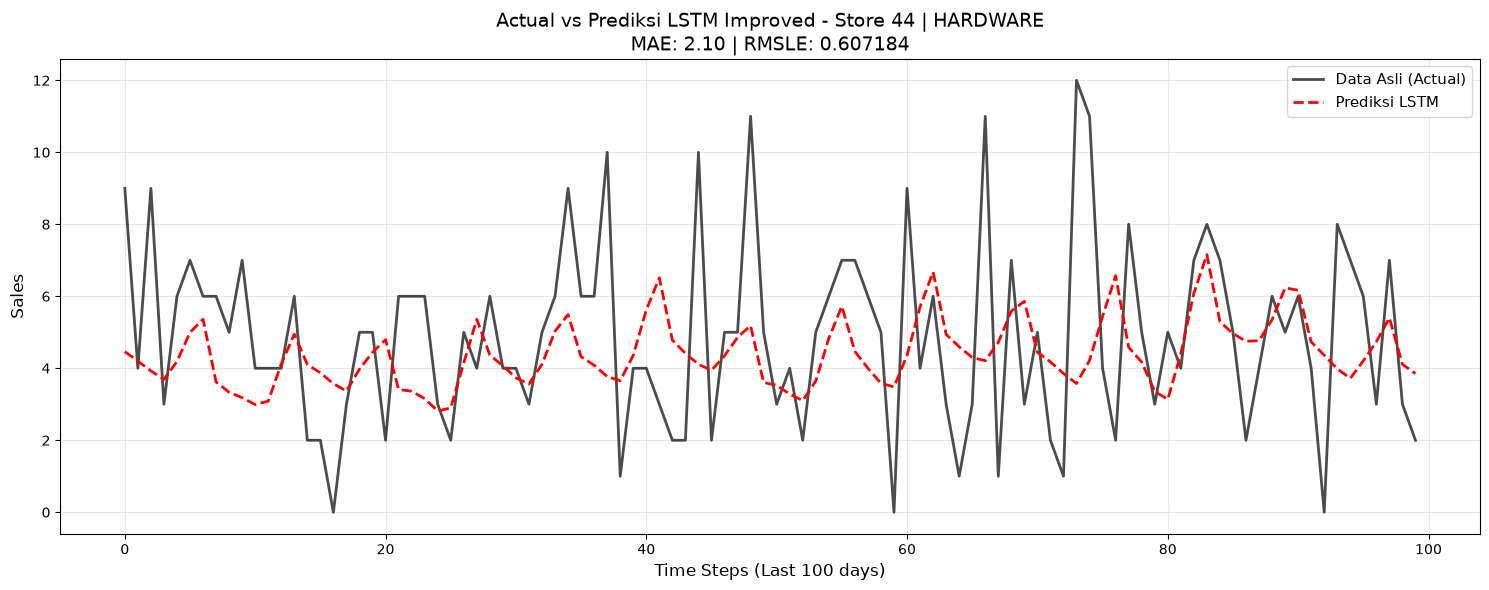


Selesai menampilkan hasil untuk semua 3 skenario.


In [12]:
# =============================================================
# Evaluasi LSTM Terbaik untuk Setiap Skenario
# =============================================================

lstm_eval_results = []

for (store, family), data in processed_data.items():
    print(f"\n{'='*70}")
    print(f"  HASIL LSTM TERBAIK: STORE {store} | FAMILY {family}")
    print(f"{'='*70}")

    tuning = all_tuning_results[(store, family)]
    best_model = tuning['best_model']
    best_history = tuning['best_history']
    best_params = tuning['best_params']

    print(f"  Parameter Terbaik: units={best_params[0]}, dropout={best_params[1]}, lr={best_params[2]}")

    # --- 1. Plot Loss Function ---
    plot_loss_history(
        best_history,
        title=f'Loss Function - Store {store} | {family}\n'
              f'(units={best_params[0]}, dropout={best_params[1]}, lr={best_params[2]})'
    )

    # --- 2. Evaluasi pada Test Set ---
    X_test = data['X_test_3d']
    y_test_actual = data['y_test_actual']
    scaler_y = data['scaler_y']

    preds_scaled = best_model.predict(X_test, verbose=0)
    preds = scaler_y.inverse_transform(preds_scaled).flatten()
    preds = np.maximum(preds, 0)

    print(f"\n  Evaluasi pada Test Set:")
    mae, rmsle = evaluate_and_print(y_test_actual, preds, label=f'LSTM Improved - {family}')

    lstm_eval_results.append({
        'Store': store,
        'Family': family,
        'Model': 'LSTM Improved',
        'MAE': mae,
        'RMSLE': rmsle,
        'Best Units': best_params[0],
        'Best Dropout': best_params[1],
        'Best LR': best_params[2]
    })

    # Simpan prediksi untuk plotting
    data['lstm_preds'] = preds

    # --- 3. Plot Actual vs Predicted ---
    plot_actual_vs_predicted(
        y_test_actual, preds,
        title=f'Actual vs Prediksi LSTM Improved - Store {store} | {family}\n'
              f'MAE: {mae:.2f} | RMSLE: {rmsle:.6f}',
        last_n=100
    )

print(f"\nSelesai menampilkan hasil untuk semua {len(processed_data)} skenario.")

In [13]:
# =============================================================
# Tabel Evaluasi LSTM Improved
# =============================================================

df_lstm_eval = pd.DataFrame(lstm_eval_results)
print('=== Evaluasi Model LSTM Improved (Test Set) ===')
display(df_lstm_eval.round(4))

=== Evaluasi Model LSTM Improved (Test Set) ===


,Store,Family,Model,MAE,RMSLE,Best Units,Best Dropout,Best LR
0,44,GROCERY I,LSTM Improved,2023.5831,0.7715,128,0.2,0.001
1,44,LAWN AND GARDEN,LSTM Improved,15.3010,0.9618,64,0.3,0.001
2,44,HARDWARE,LSTM Improved,2.1033,0.6072,32,0.2,0.010


## 5. Perbandingan Akhir: Semua Model
---
Menggabungkan hasil semua model (Baseline + LSTM Improved) dan membandingkan performa.

In [14]:
# =============================================================
# Tabel Perbandingan Semua Model
# =============================================================

# Tambahkan hasil LSTM ke all_results
all_results_final = all_results.copy()
for res in lstm_eval_results:
    all_results_final.append({
        'Store': res['Store'],
        'Family': res['Family'],
        'Model': 'LSTM Improved',
        'MAE': res['MAE'],
        'RMSLE': res['RMSLE']
    })

df_all = pd.DataFrame(all_results_final)

print('=' * 70)
print('  PERBANDINGAN SEMUA MODEL (Baseline + LSTM Improved)')
print('=' * 70)

for family in ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']:
    df_fam = df_all[df_all['Family'] == family].sort_values('MAE').reset_index(drop=True)
    print(f"\n--- {family} ---")
    display(df_fam[['Model', 'MAE', 'RMSLE']].round(4))

    best_model = df_fam.iloc[0]['Model']
    best_mae = df_fam.iloc[0]['MAE']
    if best_model == 'LSTM Improved':
        print(f"  ✅ LSTM Improved MENANG dengan MAE terbaik: {best_mae:.4f}")
    else:
        lstm_row = df_fam[df_fam['Model'] == 'LSTM Improved']
        if not lstm_row.empty:
            lstm_mae = lstm_row.iloc[0]['MAE']
            gap = lstm_mae - best_mae
            print(f"  ⚠️ {best_model} masih terbaik (MAE: {best_mae:.4f}), LSTM gap: +{gap:.4f}")

# Tabel lengkap
print(f"\n{'='*70}")
print("  TABEL LENGKAP")
print(f"{'='*70}")
display(df_all.sort_values(by=['Family', 'MAE']).reset_index(drop=True).round(4))

  PERBANDINGAN SEMUA MODEL (Baseline + LSTM Improved)

--- GROCERY I ---


,Model,MAE,RMSLE
0,XGBoost,1855.8961,0.7668
1,Seasonal Naive,1974.4438,0.7996
2,LSTM Improved,2023.5831,0.7715
3,RNN,2028.3600,0.7756


  ⚠️ XGBoost masih terbaik (MAE: 1855.8961), LSTM gap: +167.6870

--- LAWN AND GARDEN ---


,Model,MAE,RMSLE
0,XGBoost,11.8187,0.6558
1,Seasonal Naive,12.6778,0.7194
2,LSTM Improved,15.3010,0.9618
3,RNN,15.8600,0.9621


  ⚠️ XGBoost masih terbaik (MAE: 11.8187), LSTM gap: +3.4823

--- HARDWARE ---


,Model,MAE,RMSLE
0,RNN,2.0914,0.6083
1,LSTM Improved,2.1033,0.6072
2,XGBoost,2.1880,0.6164
3,Seasonal Naive,2.5350,0.7152


  ⚠️ RNN masih terbaik (MAE: 2.0914), LSTM gap: +0.0119

  TABEL LENGKAP


,Store,Family,Model,MAE,RMSLE
0,44,GROCERY I,XGBoost,1855.8961,0.7668
1,44,GROCERY I,Seasonal Naive,1974.4438,0.7996
2,44,GROCERY I,LSTM Improved,2023.5831,0.7715
3,44,GROCERY I,RNN,2028.3600,0.7756
4,44,HARDWARE,RNN,2.0914,0.6083
5,44,HARDWARE,LSTM Improved,2.1033,0.6072
6,44,HARDWARE,XGBoost,2.1880,0.6164
7,44,HARDWARE,Seasonal Naive,2.5350,0.7152
8,44,LAWN AND GARDEN,XGBoost,11.8187,0.6558
9,44,LAWN AND GARDEN,Seasonal Naive,12.6778,0.7194


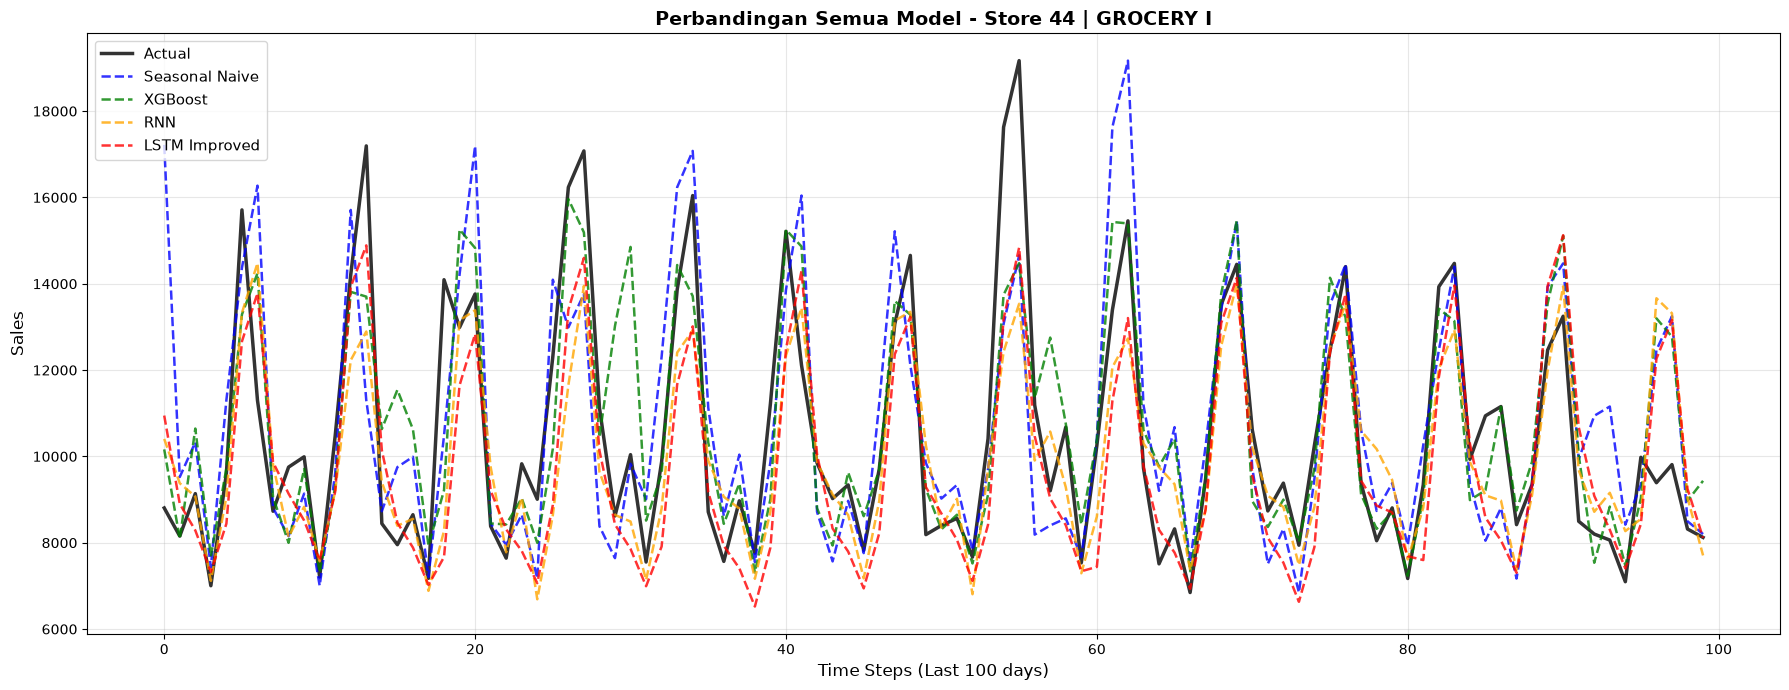

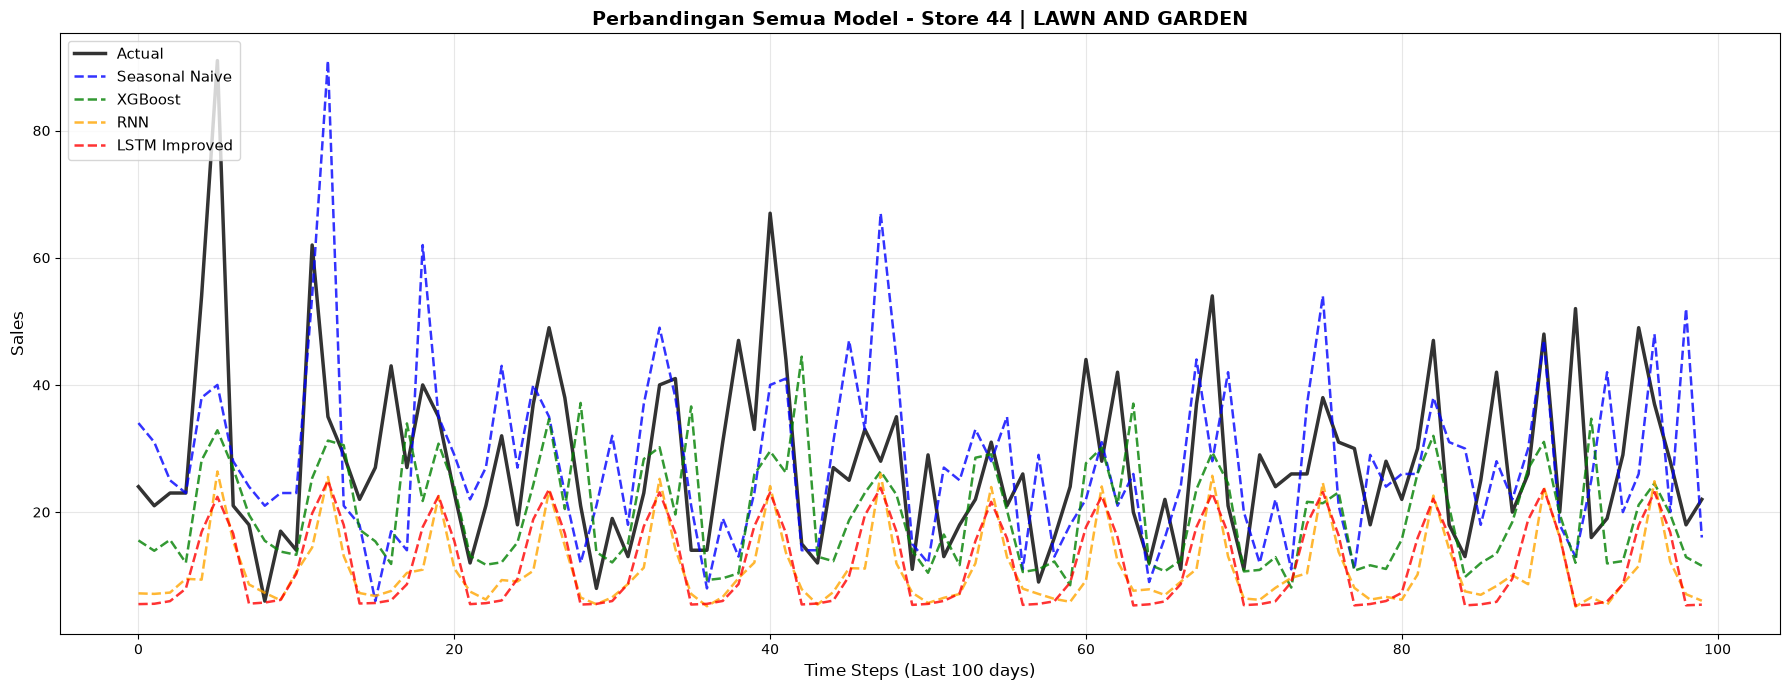

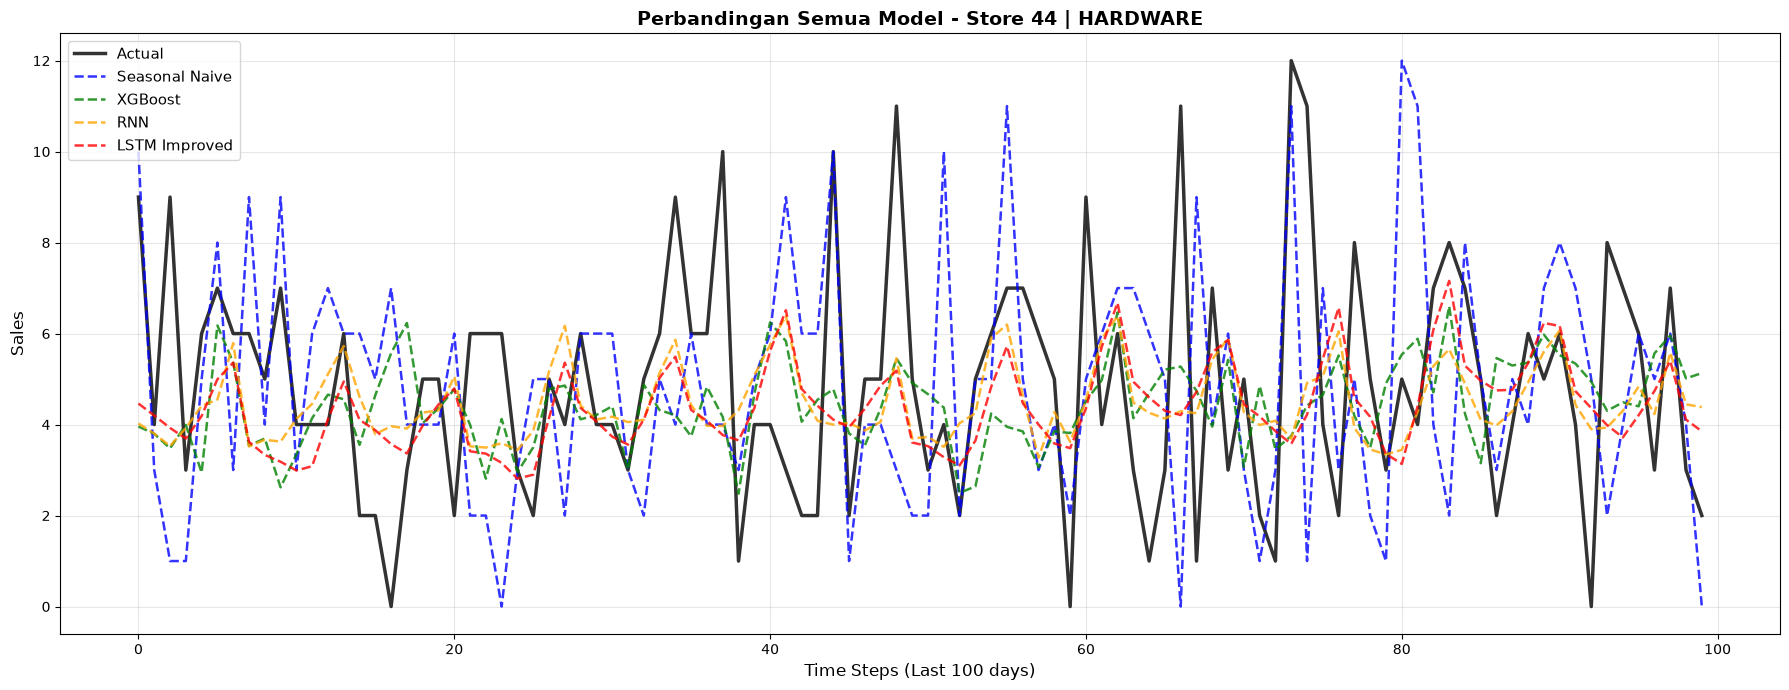

In [19]:
# =============================================================
# Plot Perbandingan Semua Model per Skenario
# =============================================================

def plot_all_models_comparison(store, family, last_n=150):
    # Plot perbandingan prediksi semua model
    if (store, family) not in processed_data:
        print(f"Data tidak ditemukan untuk Store {store} - {family}")
        return

    data = processed_data[(store, family)]
    y_actual = data['y_test_actual']

    plt.figure(figsize=(18, 7))
    plt.plot(y_actual[-last_n:], label='Actual', color='black', linewidth=2.5, alpha=0.8)

    colors = {'snaive_preds': ('blue', 'Seasonal Naive'),
              'xgb_preds': ('green', 'XGBoost'),
              'rnn_preds': ('orange', 'RNN'),
              'lstm_preds': ('red', 'LSTM Improved')}

    for key, (color, name) in colors.items():
        if key in data:
            plt.plot(data[key][-last_n:], label=name, color=color,
                     linewidth=1.8, linestyle='--', alpha=0.8)

    plt.title(f'Perbandingan Semua Model - Store {store} | {family}', fontsize=14, fontweight='bold')
    plt.xlabel(f'Time Steps (Last {last_n} days)', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.legend(fontsize=11, loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for fam in ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']:
    plot_all_models_comparison(44, fam, last_n=100)

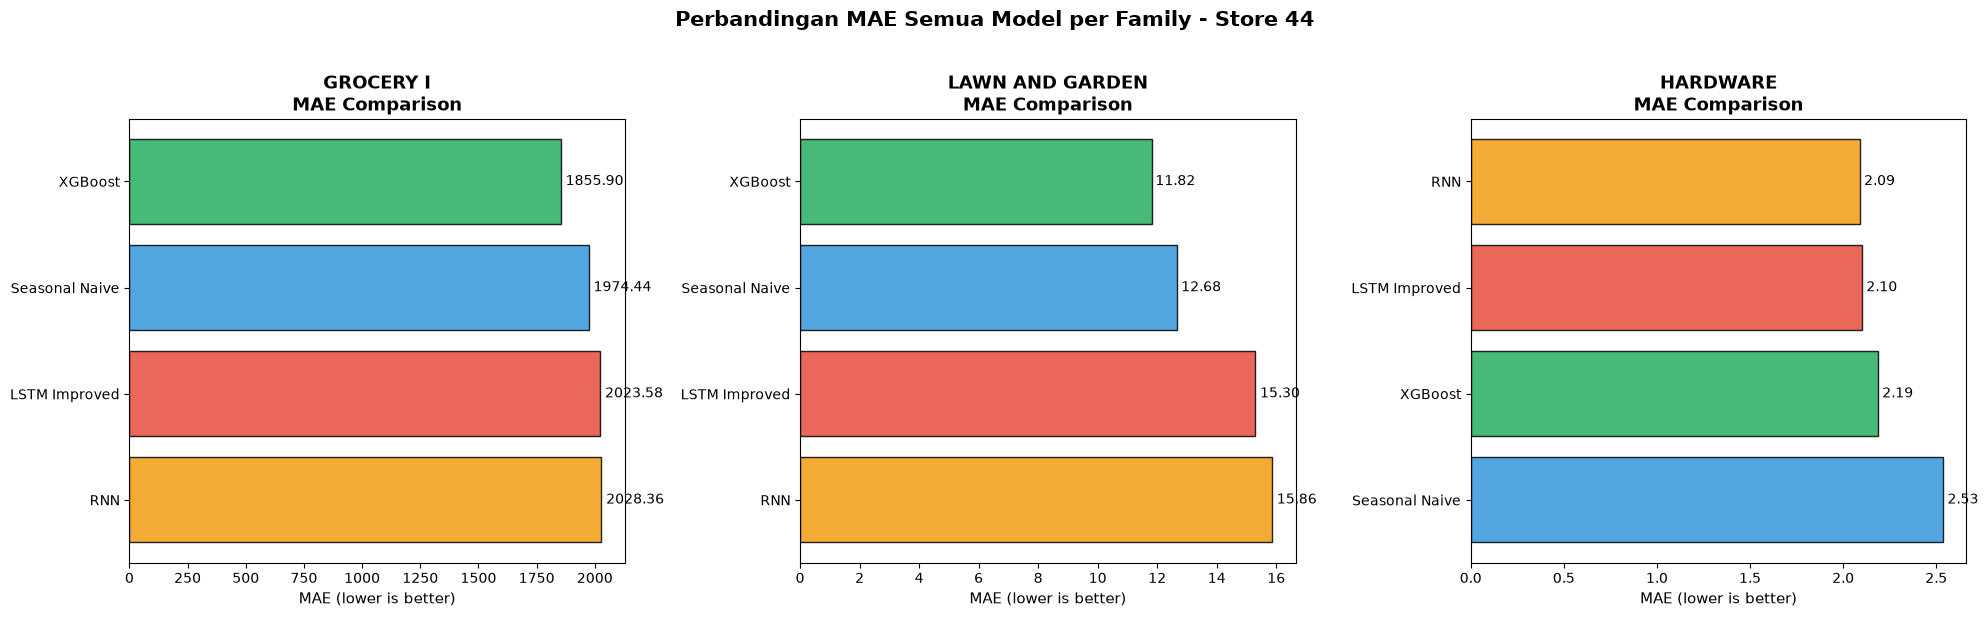

In [16]:
# =============================================================
# Bar Chart Perbandingan MAE & RMSLE per Family
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, family in enumerate(['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']):
    df_fam = df_all[df_all['Family'] == family].sort_values('MAE')

    colors_bar = []
    for m in df_fam['Model']:
        if m == 'LSTM Improved':
            colors_bar.append('#e74c3c')  # Red for LSTM
        elif m == 'RNN':
            colors_bar.append('#f39c12')  # Orange for RNN
        elif m == 'XGBoost':
            colors_bar.append('#27ae60')  # Green for XGBoost
        else:
            colors_bar.append('#3498db')  # Blue for Seasonal Naive

    axes[idx].barh(df_fam['Model'], df_fam['MAE'], color=colors_bar, edgecolor='black', alpha=0.85)
    axes[idx].set_title(f'{family}\nMAE Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('MAE (lower is better)', fontsize=11)
    axes[idx].invert_yaxis()

    # Annotate values
    for i, (mae_val, model) in enumerate(zip(df_fam['MAE'], df_fam['Model'])):
        axes[idx].text(mae_val * 1.01, i, f'{mae_val:.2f}', va='center', fontsize=10)

plt.suptitle('Perbandingan MAE Semua Model per Family - Store 44', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# =============================================================
# Ringkasan Perbaikan vs Notebook Asli
# =============================================================

print('=' * 70)
print('  RINGKASAN PERBAIKAN vs NOTEBOOK ASLI (notebook-utama.ipynb)')
print('=' * 70)

# Hasil asli dari notebook-utama.ipynb
original_results = {
    'GROCERY I': {'LSTM': 2695.93, 'RNN': 2139.41, 'XGBoost': 1731.99, 'Seasonal Naive': 1948.34},
    'LAWN AND GARDEN': {'LSTM': 13.41, 'RNN': 13.39, 'XGBoost': 13.71, 'Seasonal Naive': 12.54},
    'HARDWARE': {'LSTM': 2.15, 'RNN': 2.25, 'XGBoost': 2.22, 'Seasonal Naive': 2.53}
}

improvement_data = []

for family in ['GROCERY I', 'LAWN AND GARDEN', 'HARDWARE']:
    df_fam = df_all[df_all['Family'] == family]
    new_lstm_mae = df_fam[df_fam['Model'] == 'LSTM Improved']['MAE'].values[0]
    old_lstm_mae = original_results[family]['LSTM']

    # Check if LSTM is now the best
    best_mae = df_fam['MAE'].min()
    best_model = df_fam.loc[df_fam['MAE'].idxmin(), 'Model']
    is_lstm_best = (best_model == 'LSTM Improved')

    delta_mae = old_lstm_mae - new_lstm_mae
    pct_improvement = (delta_mae / old_lstm_mae) * 100

    improvement_data.append({
        'Family': family,
        'MAE Asli (LSTM)': old_lstm_mae,
        'MAE Baru (LSTM Improved)': round(new_lstm_mae, 4),
        'Delta MAE': round(delta_mae, 4),
        'Improvement (%)': round(pct_improvement, 2),
        'LSTM Terbaik?': '✅ Ya' if is_lstm_best else f'❌ {best_model}'
    })

    status = "✅ LSTM MENANG!" if is_lstm_best else f"⚠️ {best_model} masih terbaik"
    print(f"\n{family}:")
    print(f"  MAE Asli (LSTM):     {old_lstm_mae:.4f}")
    print(f"  MAE Baru (Improved): {new_lstm_mae:.4f}")
    print(f"  Perbaikan:           {delta_mae:.4f} ({pct_improvement:.1f}%)")
    print(f"  Status:              {status}")

df_improvement = pd.DataFrame(improvement_data)
print(f"\n{'='*70}")
display(df_improvement)

  RINGKASAN PERBAIKAN vs NOTEBOOK ASLI (notebook-utama.ipynb)

GROCERY I:
  MAE Asli (LSTM):     2695.9300
  MAE Baru (Improved): 2023.5831
  Perbaikan:           672.3469 (24.9%)
  Status:              ⚠️ XGBoost masih terbaik

LAWN AND GARDEN:
  MAE Asli (LSTM):     13.4100
  MAE Baru (Improved): 15.3010
  Perbaikan:           -1.8910 (-14.1%)
  Status:              ⚠️ XGBoost masih terbaik

HARDWARE:
  MAE Asli (LSTM):     2.1500
  MAE Baru (Improved): 2.1033
  Perbaikan:           0.0467 (2.2%)
  Status:              ⚠️ RNN masih terbaik



,Family,MAE Asli (LSTM),MAE Baru (LSTM Improved),Delta MAE,Improvement (%),LSTM Terbaik?
0,GROCERY I,2695.93,2023.5831,672.3469,24.94,❌ XGBoost
1,LAWN AND GARDEN,13.41,15.3010,-1.8910,-14.10,❌ XGBoost
2,HARDWARE,2.15,2.1033,0.0467,2.17,❌ RNN


## 6. Menyimpan Model LSTM Terbaik
---
Menyimpan model LSTM Improved terbaik untuk setiap skenario dalam format Keras.

In [18]:
# =============================================================
# Menyimpan Model LSTM Terbaik
# =============================================================

for (store, family), res in all_tuning_results.items():
    best_model = res['best_model']
    bp = res['best_params']

    filename = f"best_lstm_improved_store{store}_{family.lower().replace(' ', '_')}.keras"
    best_model.save(filename)

    print(f"Model disimpan: {filename}")
    print(f"  Parameter: units={bp[0]}, dropout={bp[1]}, lr={bp[2]}")
    print()

print("Semua model berhasil disimpan.")

Model disimpan: best_lstm_improved_store44_grocery_i.keras
  Parameter: units=128, dropout=0.2, lr=0.001

Model disimpan: best_lstm_improved_store44_lawn_and_garden.keras
  Parameter: units=64, dropout=0.3, lr=0.001

Model disimpan: best_lstm_improved_store44_hardware.keras
  Parameter: units=32, dropout=0.2, lr=0.01

Semua model berhasil disimpan.


## 7. Kesimpulan
---
### Perbaikan yang Diterapkan:

1. **Arsitektur**: Stacked 2-layer LSTM (units → units//2) + Dense intermediate (16, ReLU)
2. **Fitur**: 10 fitur (vs 3 asli) — temporal, lag, rolling statistics
3. **Lookback**: TIME_STEPS=30 (vs 14 asli)
4. **Training**: shuffle=False, batch_size=32, patience=20, ReduceLROnPlateau
5. **Hyperparameter**: units [32, 64, 128] (vs [10, 30, 50])

### Akar Masalah LSTM pada Notebook Asli:
1. Arsitektur LSTM **lebih dangkal** dari RNN (1 layer vs 2 layer)
2. Jumlah unit **terlalu kecil** (10 cells untuk GROCERY I)
3. `shuffle=True` **merusak urutan temporal** yang merupakan kekuatan utama LSTM
4. `batch_size=128` **terlalu besar** untuk ~1400 sampel
5. `patience=10` **terlalu agresif** — LSTM butuh waktu konvergensi lebih lama
6. Fitur **kurang informatif** — tidak ada sinyal temporal eksplisit